In [23]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
#Load Dataset
df = pd.read_csv(r"C:\Users\DELL\Documents\AI\IVF-AI-Sperm-Selection\data\sperm_features_extended.csv")
df.head()

,head_area,head_perimeter,tail_length,motility_score,morphology_class
0,34.98,19.30,34.64,0.403,Abnormal
1,31.17,21.42,44.63,0.290,Low_Motility
2,35.89,18.83,45.22,0.382,Abnormal
3,41.14,20.77,50.67,0.261,Normal
4,30.60,14.43,28.60,0.912,Amorphous


In [25]:
#Dataset Info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   head_area         2000 non-null   float64
 1   head_perimeter    2000 non-null   float64
 2   tail_length       2000 non-null   float64
 3   motility_score    2000 non-null   float64
 4   morphology_class  2000 non-null   object 
dtypes: float64(4), object(1)
memory usage: 78.3+ KB


,head_area,head_perimeter,tail_length,motility_score
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,32.272580,21.974240,44.424135,0.539482
std,5.924211,4.021312,11.974575,0.254210
min,15.000000,10.000000,10.000000,0.100000
25%,28.260000,19.160000,36.760000,0.327000
50%,32.265000,22.000000,44.640000,0.533500
75%,36.097500,24.660000,52.545000,0.752000
max,55.120000,37.700000,80.000000,0.999000


In [26]:
#missing values
df.isnull().sum()

head_area           0
head_perimeter      0
tail_length         0
motility_score      0
morphology_class    0
dtype: int64

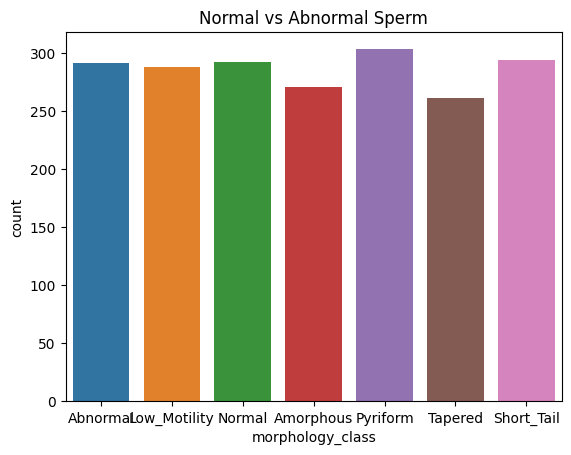

In [27]:
#Distribution of Morphology
sns.countplot(x='morphology_class', data=df)
plt.title("Normal vs Abnormal Sperm")
plt.show()

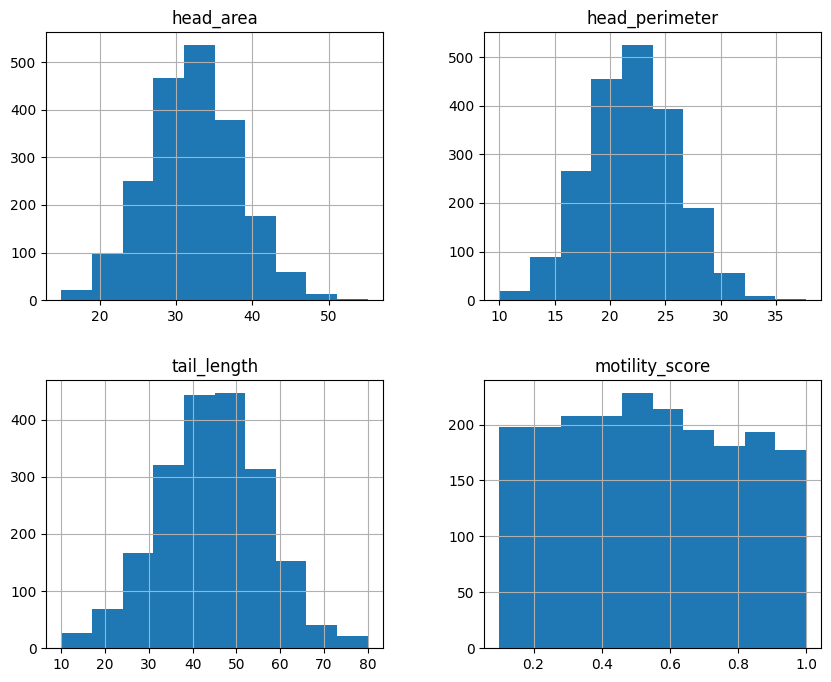

In [28]:
#Feature Distribution
df.hist(figsize=(10,8))
plt.show()

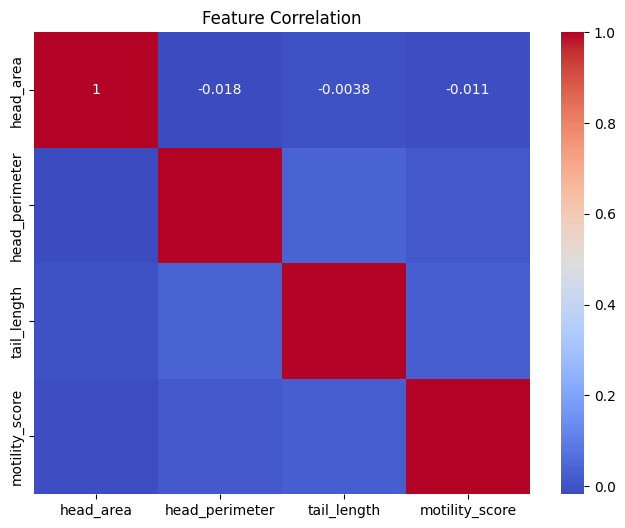

In [29]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

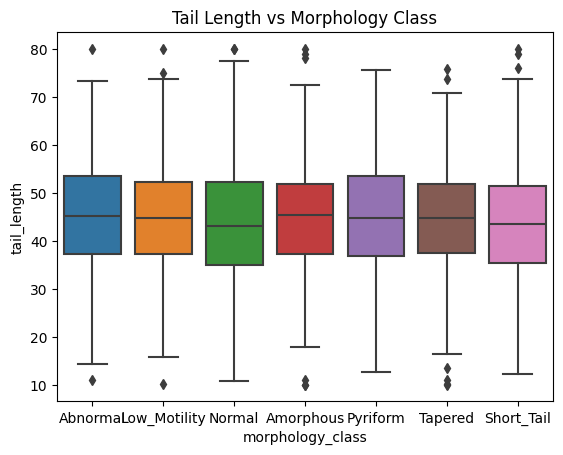

In [30]:
#Boxplot Analysis
sns.boxplot(x="morphology_class", y="tail_length", data=df)
plt.title("Tail Length vs Morphology Class")
plt.show()

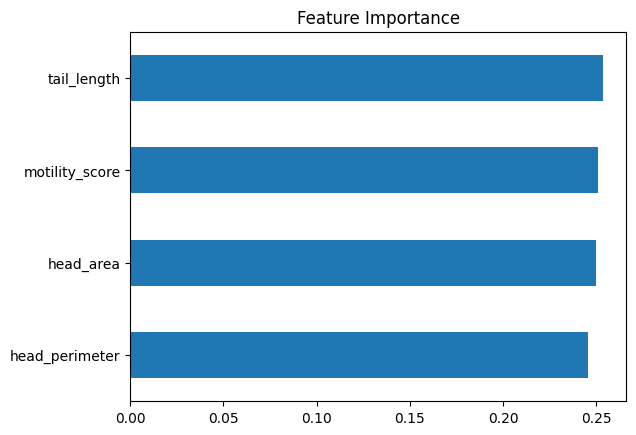

In [31]:
#Feature Importance
from sklearn.ensemble import RandomForestClassifier

X = df.drop("morphology_class", axis=1)
y = df["morphology_class"]

model = RandomForestClassifier()
model.fit(X,y)

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [32]:
#Train/Test Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
#Train Machine Learning Model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
#Model Prediction
y_pred = model.predict(X_test)
y_pred[:10]

array(['Tapered', 'Amorphous', 'Normal', 'Normal', 'Tapered',
       'Low_Motility', 'Low_Motility', 'Pyriform', 'Tapered', 'Amorphous'],
      dtype=object)

In [35]:
#Model Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Abnormal       0.17      0.13      0.15        69
   Amorphous       0.05      0.07      0.06        42
Low_Motility       0.17      0.18      0.17        56
      Normal       0.18      0.22      0.20        54
    Pyriform       0.19      0.18      0.19        61
  Short_Tail       0.16      0.18      0.17        61
     Tapered       0.09      0.07      0.08        57

    accuracy                           0.15       400
   macro avg       0.15      0.15      0.15       400
weighted avg       0.15      0.15      0.15       400



In [36]:
#Saving the Model
import joblib
joblib.dump(
    model,
    r"C:\Users\DELL\Documents\AI\IVF-AI-Sperm-Selection\models\sperm_model.pkl"
)
print("Model saved successfully")

Model saved successfully


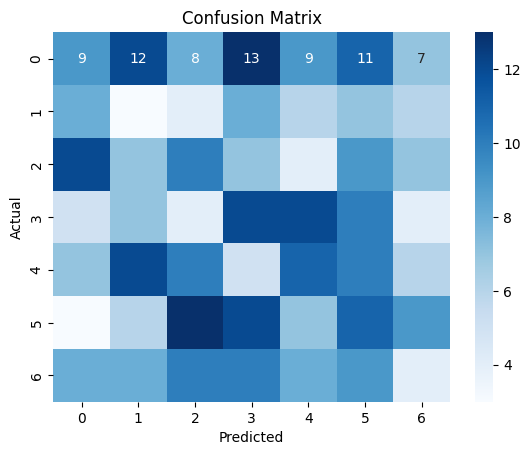

In [37]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()